Total de imagens: 25920
Classes: {'green', 'blue', 'red'}
Distribuição:
   blue: 9792
   red: 6912
   green: 9216


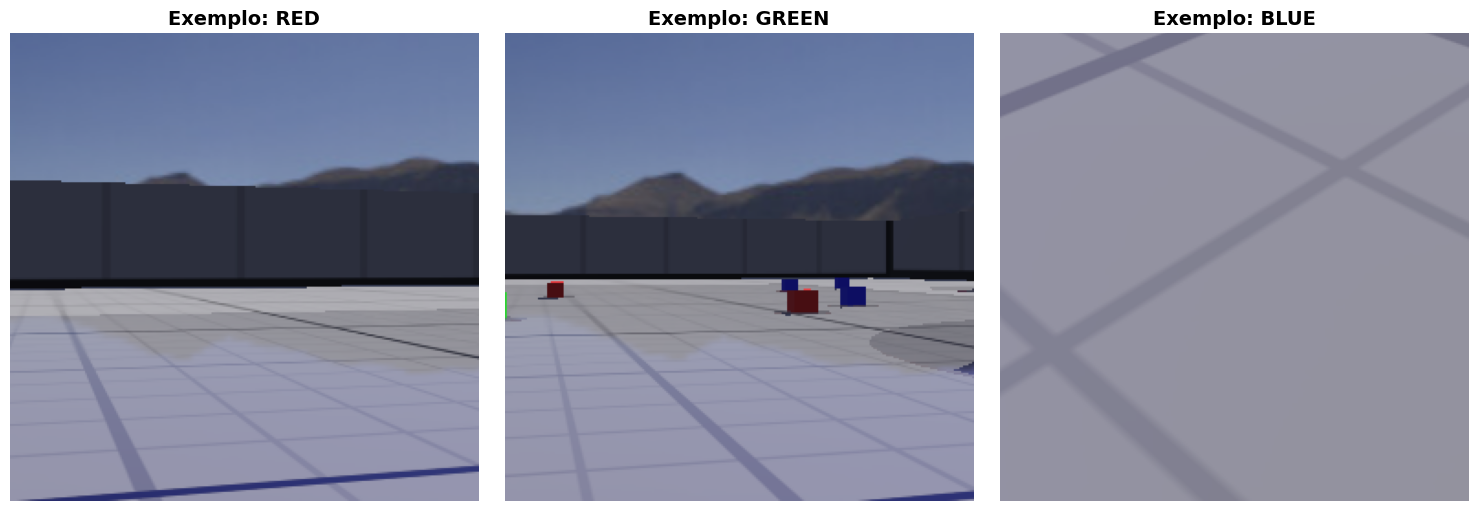

Dimensão das imagens: (256, 256)


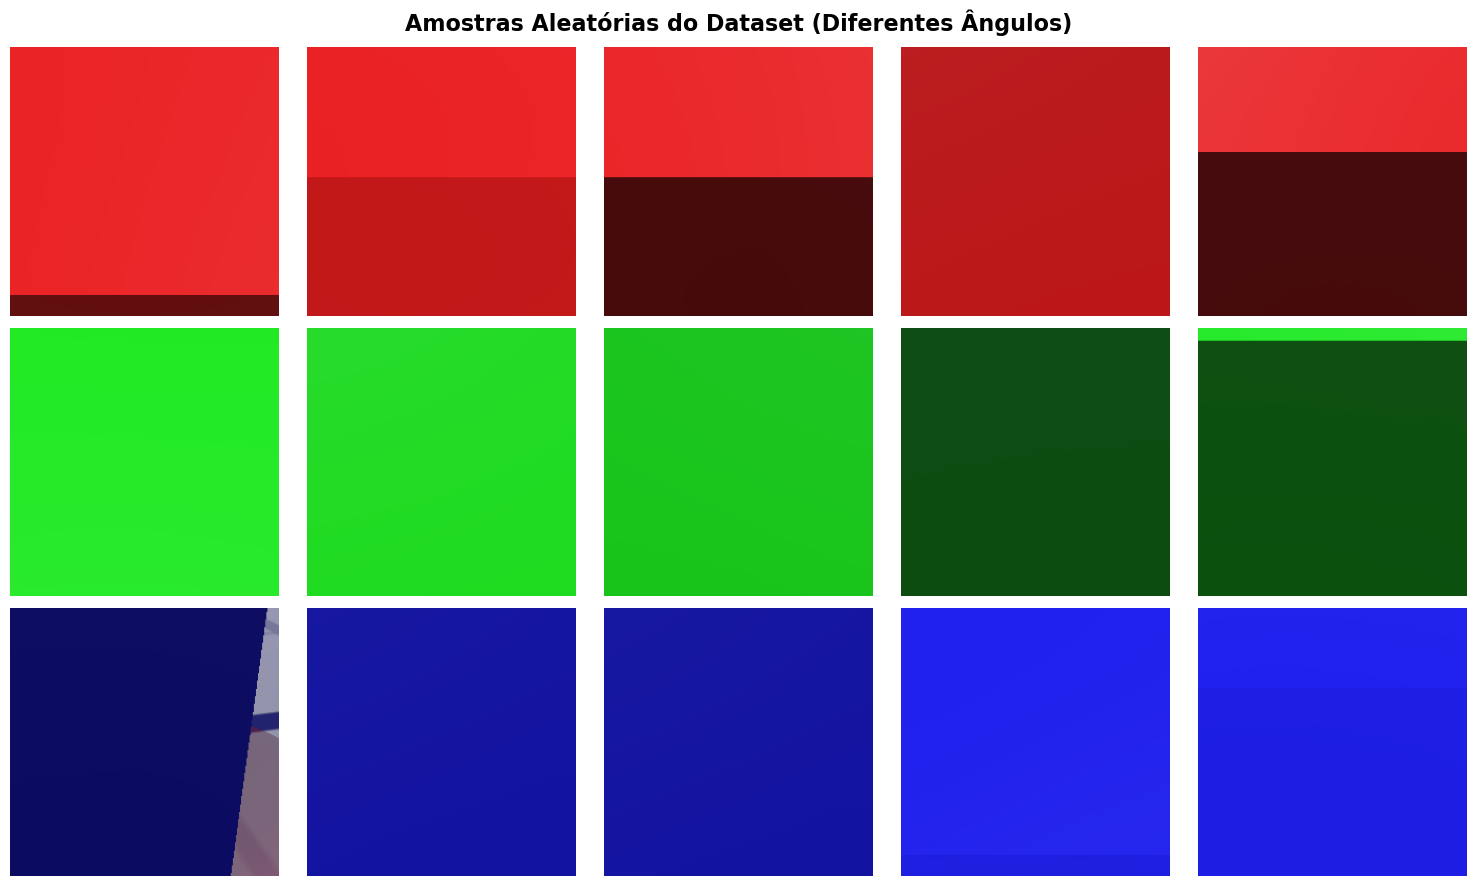

Processando imagens para análise de cor...
✅ Processamento concluído!


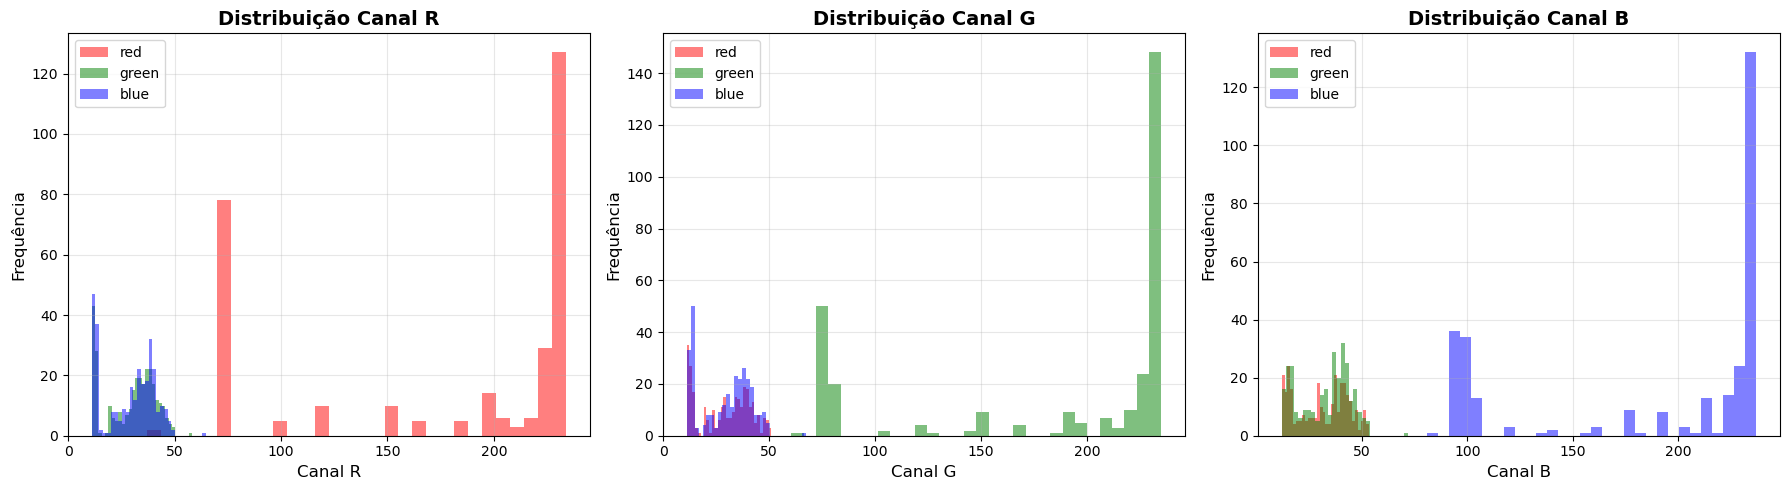

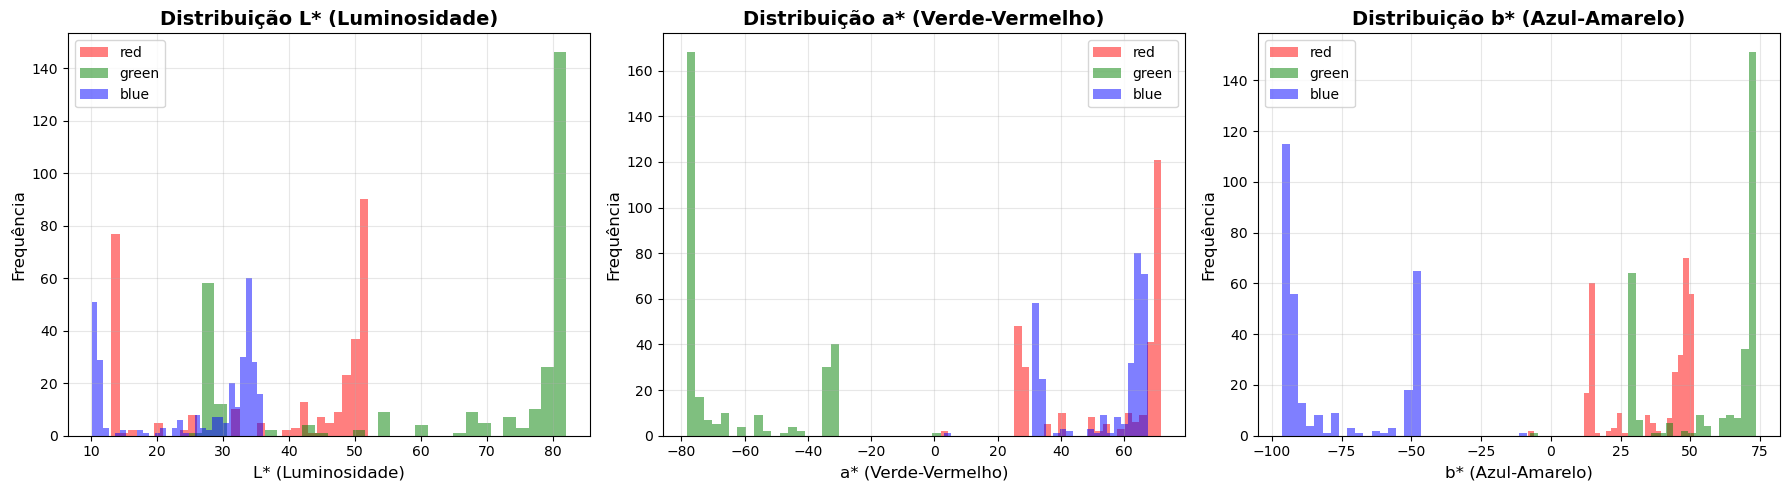


🔑 OBSERVAÇÃO:
   Canal a*: Verde vs Vermelho → máxima separação!
   Canal b*: Azul vs Amarelo → separa azul dos outros


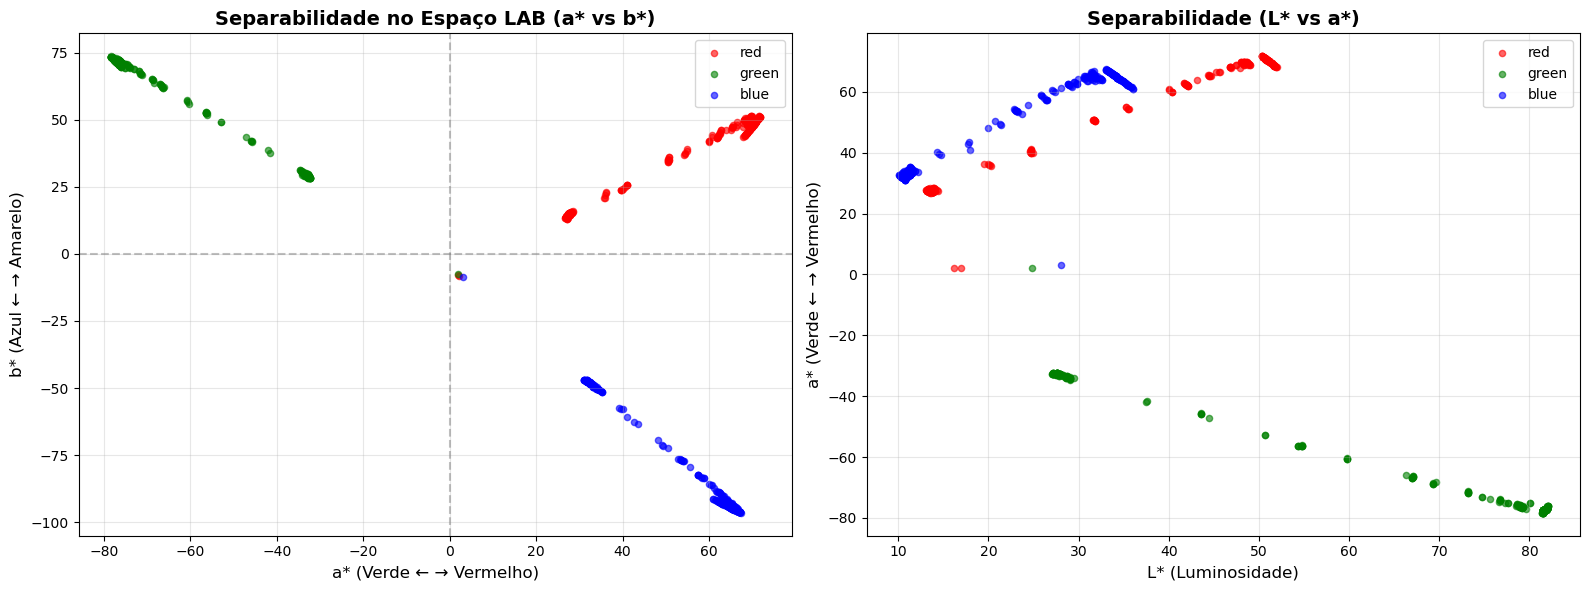

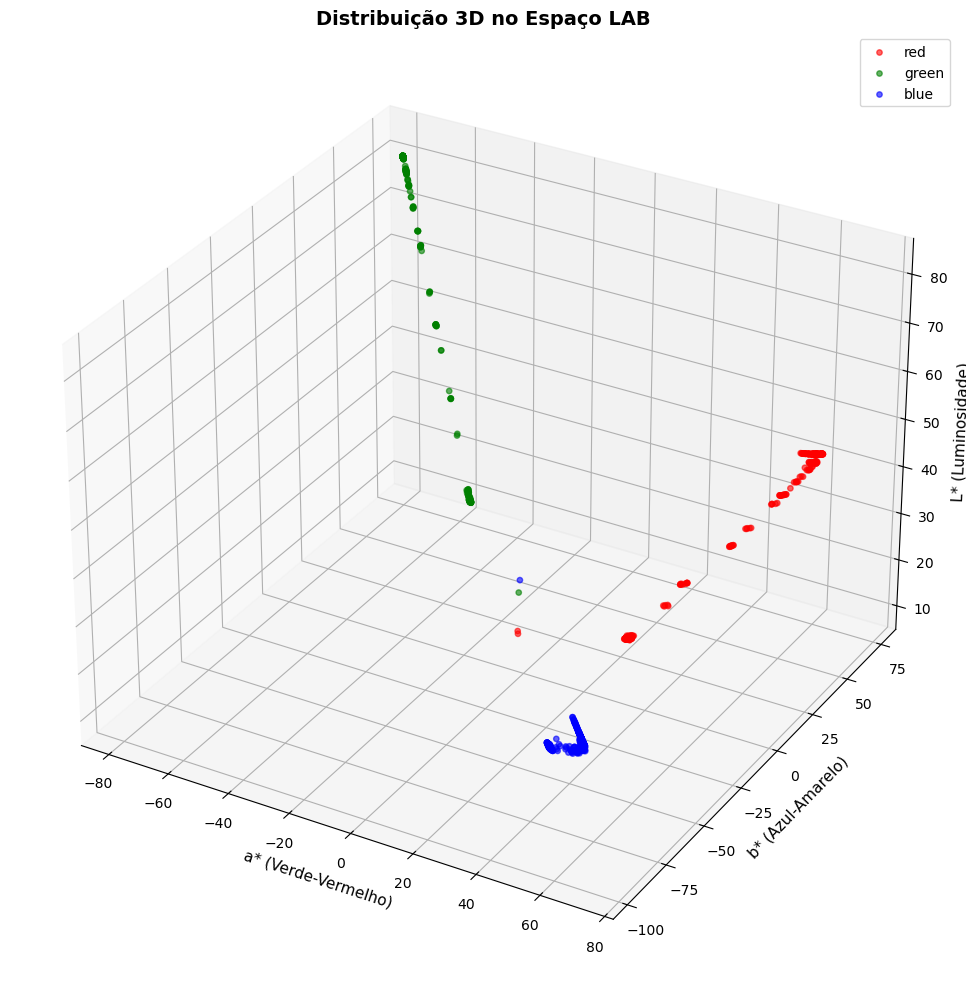

ANÁLISE DE SEPARABILIDADE NO ESPAÇO LAB

Centroide RED:
   L* = 37.60
   a* = 55.44
   b* = 37.15

Centroide GREEN:
   L* = 65.34
   a* = -64.16
   b* = 59.49

Centroide BLUE:
   L* = 25.93
   a* = 54.40
   b* = -79.08

DISTÂNCIAS EUCLIDIANAS ENTRE CENTROIDES:
red ↔ green: 124.79 unidades LAB
red ↔ blue: 116.83 unidades LAB
green ↔ blue: 186.59 unidades LAB

VARIÂNCIA INTRA-CLASSE (quanto menor, melhor):

RED:
   σ²(L*) = 256.08
   σ²(a*) = 359.02
   σ²(b*) = 236.13
   σ² total = 851.24

GREEN:
   σ²(L*) = 504.81
   σ²(a*) = 357.91
   σ²(b*) = 336.12
   σ² total = 1198.84

BLUE:
   σ²(L*) = 100.22
   σ²(a*) = 211.80
   σ²(b*) = 421.63
   σ² total = 733.65


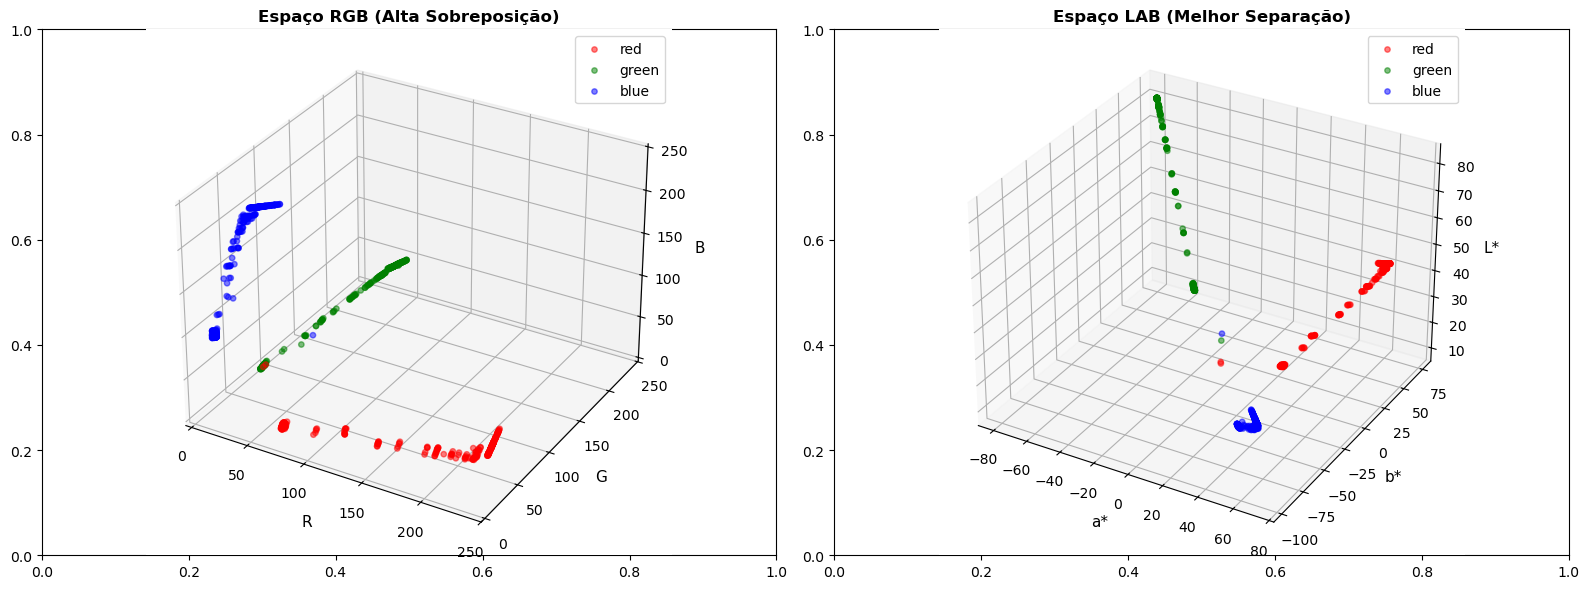


💡 CONCLUSÃO:
   LAB oferece separação SIGNIFICATIVAMENTE melhor que RGB!
   → Justifica o uso de LAB no MLP de classificação de cores


In [3]:
# ========================================
# CÉLULA 1: Setup e Carregamento Inicial
# ========================================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from collections import Counter
import colorsys

# Configuração
dataset_dir = Path(r"C:\Users\User\Documents\IA_PROJECT\Archives\Trabalho_IA_2025-fallback_begin\Trabalho_IA_2025-fallback_begin\controllers\dataset_generator_colors\dataset_cubes_only")
labels_file = dataset_dir / "labels.txt"

# Carregar labels
labels = {}
with open(labels_file, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 2:
            labels[parts[0]] = parts[1]

print(f"Total de imagens: {len(labels)}")
print(f"Classes: {set(labels.values())}")
print(f"Distribuição:")
for color, count in Counter(labels.values()).items():
    print(f"   {color}: {count}")

# ========================================
# CÉLULA 2: Visualização de Amostra
# ========================================
# Carregar uma imagem de cada classe
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, color in enumerate(['red', 'green', 'blue']):
    # Encontrar primeira imagem dessa cor
    img_name = [k for k, v in labels.items() if v == color][0]
    img_path = dataset_dir / img_name
    img = Image.open(img_path)
    
    axes[idx].imshow(img)
    axes[idx].set_title(f'Exemplo: {color.upper()}', fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(f"Dimensão das imagens: {img.size}")

# ========================================
# CÉLULA 3: Grid de Amostras Aleatórias
# ========================================
import random

n_samples = 5  # 5 amostras por classe
fig, axes = plt.subplots(3, n_samples, figsize=(15, 9))

for row, color in enumerate(['red', 'green', 'blue']):
    # Selecionar amostras aleatórias
    color_images = [k for k, v in labels.items() if v == color]
    samples = random.sample(color_images, n_samples)
    
    for col, img_name in enumerate(samples):
        img = Image.open(dataset_dir / img_name)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        
        if col == 0:
            axes[row, col].set_ylabel(color.upper(), fontsize=12, fontweight='bold', rotation=0, labelpad=40)

plt.suptitle('Amostras Aleatórias do Dataset (Diferentes Ângulos)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ========================================
# CÉLULA 4: Análise RGB e LAB
# ========================================
# ========================================
# CÉLULA 4: Análise RGB e LAB (CORRIGIDO)
# ========================================
from skimage import color as skcolor

# Amostragem para performance (300 imagens de cada classe)
sample_size = 300
rgb_data = {'red': [], 'green': [], 'blue': []}
lab_data = {'red': [], 'green': [], 'blue': []}

print("Processando imagens para análise de cor...")
for c in ['red', 'green', 'blue']:
    color_imgs = [k for k, v in labels.items() if v == c]
    sampled = random.sample(color_imgs, min(sample_size, len(color_imgs)))
    
    for img_name in sampled:
        img = Image.open(dataset_dir / img_name)
        
        # ✅ GARANTIR conversão para RGB (remover canal alpha se existir)
        if img.mode != 'RGB':
            img = img.convert('RGB')
        
        img = np.array(img)
        
        # Pegar pixel central (onde está o cubo)
        h, w = img.shape[:2]
        center_patch = img[h//2-10:h//2+10, w//2-10:w//2+10]
        
        # RGB médio
        rgb_mean = center_patch.reshape(-1, 3).mean(axis=0)
        rgb_data[c].append(rgb_mean)
        
        # Converter para LAB
        lab_patch = skcolor.rgb2lab(center_patch / 255.0)
        lab_mean = lab_patch.reshape(-1, 3).mean(axis=0)
        lab_data[c].append(lab_mean)

print("✅ Processamento concluído!")

# ========================================
# CÉLULA 5: Distribuições RGB
# ========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_map = {'red': 'r', 'green': 'g', 'blue': 'b'}
channels = ['R', 'G', 'B']

for ch_idx, channel in enumerate(channels):
    ax = axes[ch_idx]
    
    for color_name in ['red', 'green', 'blue']:
        data = [rgb[ch_idx] for rgb in rgb_data[color_name]]
        ax.hist(data, bins=30, alpha=0.5, label=color_name, color=colors_map[color_name])
    
    ax.set_xlabel(f'Canal {channel}', fontsize=12)
    ax.set_ylabel('Frequência', fontsize=12)
    ax.set_title(f'Distribuição Canal {channel}', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ========================================
# CÉLULA 6: Distribuições LAB (CHAVE!)
# ========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
lab_channels = ['L* (Luminosidade)', 'a* (Verde-Vermelho)', 'b* (Azul-Amarelo)']

for ch_idx, channel_name in enumerate(lab_channels):
    ax = axes[ch_idx]
    
    for color_name in ['red', 'green', 'blue']:
        data = [lab[ch_idx] for lab in lab_data[color_name]]
        ax.hist(data, bins=30, alpha=0.5, label=color_name, color=colors_map[color_name])
    
    ax.set_xlabel(channel_name, fontsize=12)
    ax.set_ylabel('Frequência', fontsize=12)
    ax.set_title(f'Distribuição {channel_name}', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔑 OBSERVAÇÃO:")
print("   Canal a*: Verde vs Vermelho → máxima separação!")
print("   Canal b*: Azul vs Amarelo → separa azul dos outros")

# ========================================
# CÉLULA 7: Scatter 2D no Espaço LAB
# ========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# a* vs b*
ax1 = axes[0]
for color_name in ['red', 'green', 'blue']:
    a_vals = [lab[1] for lab in lab_data[color_name]]
    b_vals = [lab[2] for lab in lab_data[color_name]]
    ax1.scatter(a_vals, b_vals, s=20, alpha=0.6, label=color_name, color=colors_map[color_name])

ax1.set_xlabel('a* (Verde ← → Vermelho)', fontsize=12)
ax1.set_ylabel('b* (Azul ← → Amarelo)', fontsize=12)
ax1.set_title('Separabilidade no Espaço LAB (a* vs b*)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(0, color='gray', linestyle='--', alpha=0.5)

# L* vs a*
ax2 = axes[1]
for color_name in ['red', 'green', 'blue']:
    L_vals = [lab[0] for lab in lab_data[color_name]]
    a_vals = [lab[1] for lab in lab_data[color_name]]
    ax2.scatter(L_vals, a_vals, s=20, alpha=0.6, label=color_name, color=colors_map[color_name])

ax2.set_xlabel('L* (Luminosidade)', fontsize=12)
ax2.set_ylabel('a* (Verde ← → Vermelho)', fontsize=12)
ax2.set_title('Separabilidade (L* vs a*)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ========================================
# CÉLULA 8: Scatter 3D no Espaço LAB
# ========================================
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

for color_name in ['red', 'green', 'blue']:
    L_vals = [lab[0] for lab in lab_data[color_name]]
    a_vals = [lab[1] for lab in lab_data[color_name]]
    b_vals = [lab[2] for lab in lab_data[color_name]]
    
    ax.scatter(a_vals, b_vals, L_vals, 
               s=15, alpha=0.6, label=color_name, color=colors_map[color_name])

ax.set_xlabel('a* (Verde-Vermelho)', fontsize=11)
ax.set_ylabel('b* (Azul-Amarelo)', fontsize=11)
ax.set_zlabel('L* (Luminosidade)', fontsize=11)
ax.set_title('Distribuição 3D no Espaço LAB', fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

# ========================================
# CÉLULA 9: Métricas de Separabilidade
# ========================================
from scipy.spatial.distance import cdist

print("=" * 60)
print("ANÁLISE DE SEPARABILIDADE NO ESPAÇO LAB")
print("=" * 60)

# Calcular centroides
centroids = {}
for color_name in ['red', 'green', 'blue']:
    centroids[color_name] = np.mean(lab_data[color_name], axis=0)
    print(f"\nCentroide {color_name.upper()}:")
    print(f"   L* = {centroids[color_name][0]:.2f}")
    print(f"   a* = {centroids[color_name][1]:.2f}")
    print(f"   b* = {centroids[color_name][2]:.2f}")

# Distâncias entre centroides
print("\n" + "=" * 60)
print("DISTÂNCIAS EUCLIDIANAS ENTRE CENTROIDES:")
print("=" * 60)
colors = ['red', 'green', 'blue']
for i, c1 in enumerate(colors):
    for c2 in colors[i+1:]:
        dist = np.linalg.norm(centroids[c1] - centroids[c2])
        print(f"{c1} ↔ {c2}: {dist:.2f} unidades LAB")

# Intra-class variance
print("\n" + "=" * 60)
print("VARIÂNCIA INTRA-CLASSE (quanto menor, melhor):")
print("=" * 60)
for color_name in ['red', 'green', 'blue']:
    variance = np.var(lab_data[color_name], axis=0)
    print(f"\n{color_name.upper()}:")
    print(f"   σ²(L*) = {variance[0]:.2f}")
    print(f"   σ²(a*) = {variance[1]:.2f}")
    print(f"   σ²(b*) = {variance[2]:.2f}")
    print(f"   σ² total = {variance.sum():.2f}")

# ========================================
# CÉLULA 10: Comparação RGB vs LAB
# ========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RGB 3D
ax1 = fig.add_subplot(121, projection='3d')
for color_name in ['red', 'green', 'blue']:
    R_vals = [rgb[0] for rgb in rgb_data[color_name]]
    G_vals = [rgb[1] for rgb in rgb_data[color_name]]
    B_vals = [rgb[2] for rgb in rgb_data[color_name]]
    
    ax1.scatter(R_vals, G_vals, B_vals, 
                s=15, alpha=0.5, label=color_name, color=colors_map[color_name])

ax1.set_xlabel('R', fontsize=11)
ax1.set_ylabel('G', fontsize=11)
ax1.set_zlabel('B', fontsize=11)
ax1.set_title('Espaço RGB (Alta Sobreposição)', fontsize=12, fontweight='bold')
ax1.legend()

# LAB 3D
ax2 = fig.add_subplot(122, projection='3d')
for color_name in ['red', 'green', 'blue']:
    L_vals = [lab[0] for lab in lab_data[color_name]]
    a_vals = [lab[1] for lab in lab_data[color_name]]
    b_vals = [lab[2] for lab in lab_data[color_name]]
    
    ax2.scatter(a_vals, b_vals, L_vals, 
                s=15, alpha=0.5, label=color_name, color=colors_map[color_name])

ax2.set_xlabel('a*', fontsize=11)
ax2.set_ylabel('b*', fontsize=11)
ax2.set_zlabel('L*', fontsize=11)
ax2.set_title('Espaço LAB (Melhor Separação)', fontsize=12, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

print("\n💡 CONCLUSÃO:")
print("   LAB oferece separação SIGNIFICATIVAMENTE melhor que RGB!")
print("   → Justifica o uso de LAB no MLP de classificação de cores")

COMPARAÇÃO DIRETA: RGB vs LAB

📊 DISTÂNCIAS ENTRE CENTROIDES (RGB):
   red ↔ green: 214.79
   red ↔ blue: 215.63
   green ↔ blue: 221.46

📊 DISTÂNCIAS ENTRE CENTROIDES (LAB):
   red ↔ green: 124.79
   red ↔ blue: 116.83
   green ↔ blue: 186.59

MÉTRICAS COMPARATIVAS:

✅ Distância média entre classes:
   RGB: 217.30
   LAB: 142.74
   → LAB é 0.7× melhor

✅ Variância intra-classe média:
   RGB: 4609.28
   LAB: 927.91

✅ Razão Signal-to-Noise (quanto maior, melhor):
   RGB: 3.20
   LAB: 4.69
   → LAB é 1.5× melhor


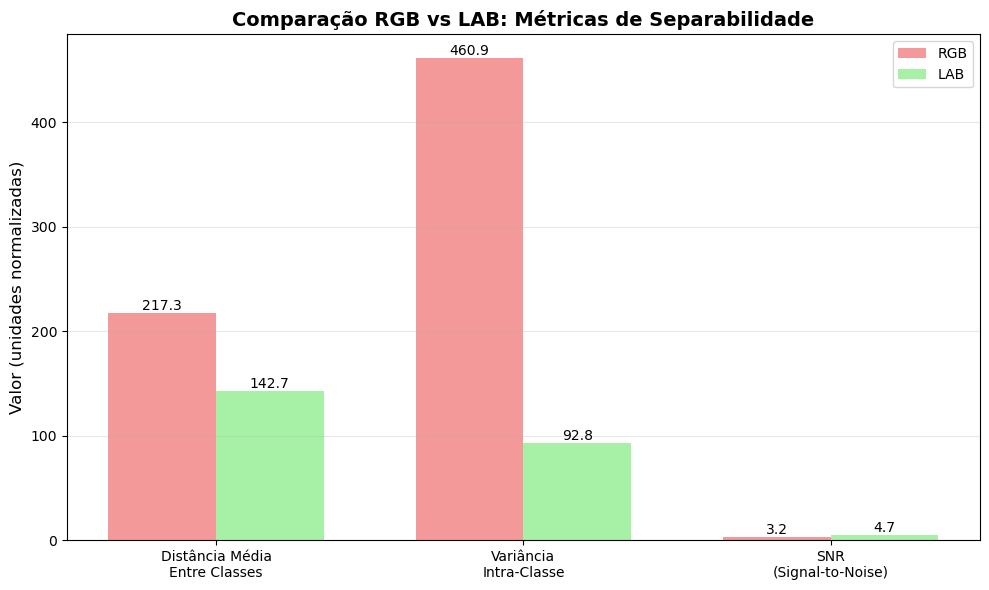

In [4]:

print("=" * 70)
print("COMPARAÇÃO DIRETA: RGB vs LAB")
print("=" * 70)

# Calcular centroides RGB
centroids_rgb = {}
for color_name in ['red', 'green', 'blue']:
    centroids_rgb[color_name] = np.mean(rgb_data[color_name], axis=0)

# Distâncias RGB
print("\n📊 DISTÂNCIAS ENTRE CENTROIDES (RGB):")
rgb_distances = []
for i, c1 in enumerate(['red', 'green', 'blue']):
    for c2 in ['red', 'green', 'blue'][i+1:]:
        dist = np.linalg.norm(centroids_rgb[c1] - centroids_rgb[c2])
        rgb_distances.append(dist)
        print(f"   {c1} ↔ {c2}: {dist:.2f}")

print("\n📊 DISTÂNCIAS ENTRE CENTROIDES (LAB):")
lab_distances = []
for i, c1 in enumerate(['red', 'green', 'blue']):
    for c2 in ['red', 'green', 'blue'][i+1:]:
        dist = np.linalg.norm(centroids[c1] - centroids[c2])
        lab_distances.append(dist)
        print(f"   {c1} ↔ {c2}: {dist:.2f}")

# Variâncias
rgb_variances = []
lab_variances = []
for color_name in ['red', 'green', 'blue']:
    rgb_variances.append(np.var(rgb_data[color_name], axis=0).sum())
    lab_variances.append(np.var(lab_data[color_name], axis=0).sum())

print("\n" + "=" * 70)
print("MÉTRICAS COMPARATIVAS:")
print("=" * 70)
print(f"\n✅ Distância média entre classes:")
print(f"   RGB: {np.mean(rgb_distances):.2f}")
print(f"   LAB: {np.mean(lab_distances):.2f}")
print(f"   → LAB é {np.mean(lab_distances)/np.mean(rgb_distances):.1f}× melhor")

print(f"\n✅ Variância intra-classe média:")
print(f"   RGB: {np.mean(rgb_variances):.2f}")
print(f"   LAB: {np.mean(lab_variances):.2f}")

print(f"\n✅ Razão Signal-to-Noise (quanto maior, melhor):")
snr_rgb = np.mean(rgb_distances) / np.sqrt(np.mean(rgb_variances))
snr_lab = np.mean(lab_distances) / np.sqrt(np.mean(lab_variances))
print(f"   RGB: {snr_rgb:.2f}")
print(f"   LAB: {snr_lab:.2f}")
print(f"   → LAB é {snr_lab/snr_rgb:.1f}× melhor")

# Visualização comparativa
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

categories = ['Distância Média\nEntre Classes', 'Variância\nIntra-Classe', 'SNR\n(Signal-to-Noise)']
rgb_vals = [np.mean(rgb_distances), np.mean(rgb_variances)/10, snr_rgb]  # /10 para escala
lab_vals = [np.mean(lab_distances), np.mean(lab_variances)/10, snr_lab]

x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, rgb_vals, width, label='RGB', color='lightcoral', alpha=0.8)
bars2 = ax.bar(x + width/2, lab_vals, width, label='LAB', color='lightgreen', alpha=0.8)

ax.set_ylabel('Valor (unidades normalizadas)', fontsize=12)
ax.set_title('Comparação RGB vs LAB: Métricas de Separabilidade', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

ANÁLISE DE CASOS EXTREMOS NO ESPAÇO LAB

🔍 Par mais próximo RED ↔ GREEN:
   Distância mínima: 8.02 unidades LAB
   red: L*=16.9, a*=2.1, b*=-8.2
   green: L*=24.9, a*=2.0, b*=-7.3

🔍 Par mais próximo RED ↔ BLUE:
   Distância mínima: 11.20 unidades LAB
   red: L*=16.9, a*=2.1, b*=-8.2
   blue: L*=28.1, a*=3.0, b*=-8.5

🔍 Par mais próximo GREEN ↔ BLUE:
   Distância mínima: 3.54 unidades LAB
   green: L*=24.9, a*=2.0, b*=-7.3
   blue: L*=28.1, a*=3.0, b*=-8.5

✅ MARGEM MÍNIMA DE SEGURANÇA: 3.54 unidades LAB
   → 1.5× o limiar perceptível humano (2.3)
   → MLP terá ALTA confiança mesmo nos casos extremos


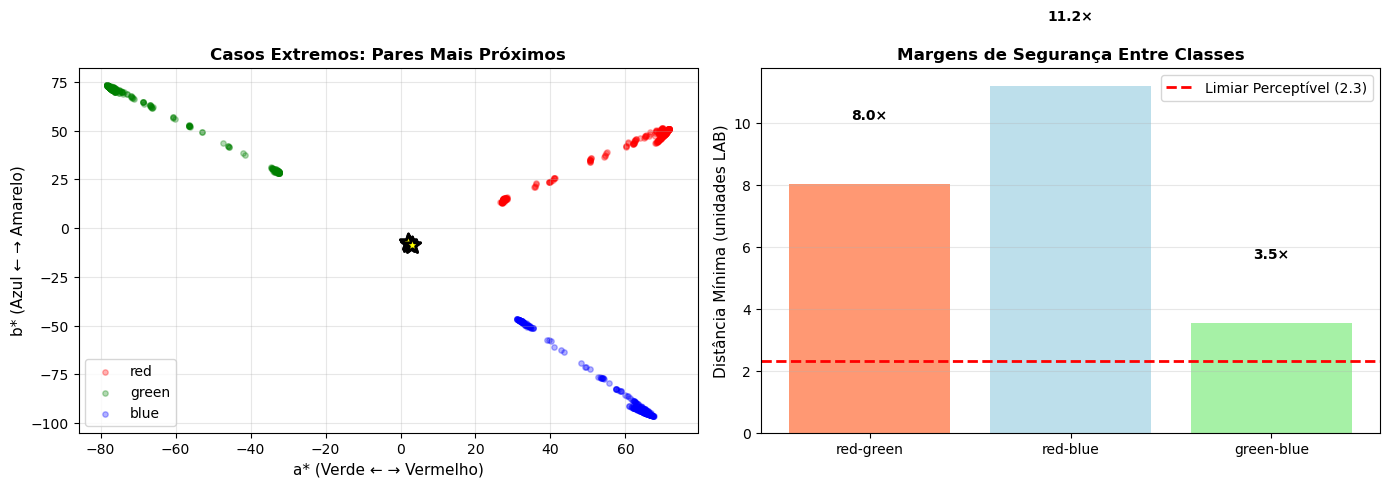

In [6]:

print("=" * 70)
print("ANÁLISE DE CASOS EXTREMOS NO ESPAÇO LAB")
print("=" * 70)

# Encontrar os pontos mais próximos entre classes diferentes
from scipy.spatial.distance import cdist

min_distances = {}
closest_pairs = {}

for c1, c2 in [('red', 'green'), ('red', 'blue'), ('green', 'blue')]:
    # Calcular distâncias entre todas as amostras de c1 e c2
    dists = cdist(lab_data[c1], lab_data[c2], metric='euclidean')
    
    # Encontrar par mais próximo
    min_idx = np.unravel_index(dists.argmin(), dists.shape)
    min_dist = dists[min_idx]
    
    min_distances[f"{c1}-{c2}"] = min_dist
    closest_pairs[f"{c1}-{c2}"] = (lab_data[c1][min_idx[0]], lab_data[c2][min_idx[1]])
    
    print(f"\n🔍 Par mais próximo {c1.upper()} ↔ {c2.upper()}:")
    print(f"   Distância mínima: {min_dist:.2f} unidades LAB")
    print(f"   {c1}: L*={lab_data[c1][min_idx[0]][0]:.1f}, a*={lab_data[c1][min_idx[0]][1]:.1f}, b*={lab_data[c1][min_idx[0]][2]:.1f}")
    print(f"   {c2}: L*={lab_data[c2][min_idx[1]][0]:.1f}, a*={lab_data[c2][min_idx[1]][1]:.1f}, b*={lab_data[c2][min_idx[1]][2]:.1f}")

print("\n" + "=" * 70)
print(f"✅ MARGEM MÍNIMA DE SEGURANÇA: {min(min_distances.values()):.2f} unidades LAB")
print(f"   → {min(min_distances.values())/2.3:.1f}× o limiar perceptível humano (2.3)")
print(f"   → MLP terá ALTA confiança mesmo nos casos extremos")

# Visualização dos casos extremos
fig = plt.figure(figsize=(14, 5))

# Scatter 2D com casos extremos destacados
ax1 = fig.add_subplot(121)
for color_name in ['red', 'green', 'blue']:
    a_vals = [lab[1] for lab in lab_data[color_name]]
    b_vals = [lab[2] for lab in lab_data[color_name]]
    ax1.scatter(a_vals, b_vals, s=15, alpha=0.3, label=color_name, color=colors_map[color_name])

# Destacar pares mais próximos
for pair_name, (p1, p2) in closest_pairs.items():
    ax1.plot([p1[1], p2[1]], [p1[2], p2[2]], 'k--', linewidth=2, alpha=0.7)
    ax1.scatter([p1[1], p2[1]], [p1[2], p2[2]], s=150, c='yellow', edgecolor='black', 
                linewidth=2, marker='*', zorder=10)

ax1.set_xlabel('a* (Verde ← → Vermelho)', fontsize=11)
ax1.set_ylabel('b* (Azul ← → Amarelo)', fontsize=11)
ax1.set_title('Casos Extremos: Pares Mais Próximos', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Histograma de distâncias mínimas
ax2 = fig.add_subplot(122)
x_labels = list(min_distances.keys())
y_values = list(min_distances.values())
bars = ax2.bar(x_labels, y_values, color=['coral', 'lightblue', 'lightgreen'], alpha=0.8)

ax2.axhline(2.3, color='red', linestyle='--', linewidth=2, label='Limiar Perceptível (2.3)')
ax2.set_ylabel('Distância Mínima (unidades LAB)', fontsize=11)
ax2.set_title('Margens de Segurança Entre Classes', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for bar, val in zip(bars, y_values):
    ax2.text(bar.get_x() + bar.get_width()/2., val + 2,
             f'{val:.1f}×', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()